<a href="https://colab.research.google.com/github/CHENNURUHARISH/PLANT-LEAF-DISEASE-DETECTION/blob/main/PLANT_DISEASE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!nvidia-smi


Fri Mar  7 22:30:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             29W /   70W |    3708MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [32]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential


In [33]:



from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Preprocessing
# Train image Processing

In [35]:
# Load training dataset from directory (variable name: train_ds)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",  # Direct path to training images
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


# Load validation dataset from directory (variable name: valid_ds)
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",  # Direct path to validation images
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,  # No shuffling for validation set
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


# Print class names for both training and validation sets
print("Training Set Classes:", train_dataset.class_names)
#print("Validation Set Classes:", valid_ds.class_names)





Found 3813 files belonging to 37 classes.
Found 3795 files belonging to 37 classes.
Training Set Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Sept

In [36]:


### Data Augmentation & Normalization

from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast, RandomTranslation
# Define Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),  # Randomly flip images horizontally
    tf.keras.layers.RandomRotation(0.2),  # Rotate images randomly by 20%
    tf.keras.layers.RandomZoom(0.2),  # Zoom in/out by 20%
    tf.keras.layers.RandomContrast(0.2)  # Adjust contrast by 20%
])

# Apply Data Augmentation only to training dataset
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))

# Normalize images (scale pixel values to [0,1])
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

In [37]:


train_dataset


for x,y in train_dataset:
  print(x, x.shape)
  print(y, y.shape)
  break


tf.Tensor(
[[[[1.0377931e-01 1.6620213e-01 1.0689890e-01]
   [1.8590833e-01 2.6071280e-01 1.7922625e-01]
   [3.8264546e-01 4.7868726e-01 3.6990300e-01]
   ...
   [7.2064894e-01 7.1191645e-01 7.8097397e-01]
   [7.1440834e-01 7.0057291e-01 7.7079672e-01]
   [7.0163637e-01 6.8630040e-01 7.5680202e-01]]

  [[0.0000000e+00 4.1172046e-02 4.6883980e-03]
   [6.7684583e-02 1.2617972e-01 6.2559366e-02]
   [2.3087411e-01 3.1127977e-01 2.1271789e-01]
   ...
   [7.1234041e-01 7.0917171e-01 7.7680194e-01]
   [7.2724330e-01 7.1652573e-01 7.8607768e-01]
   [7.2179812e-01 7.0723957e-01 7.7767491e-01]]

  [[0.0000000e+00 1.6189396e-02 6.6439165e-03]
   [7.9908185e-03 5.1874861e-02 1.4355649e-02]
   [9.5585637e-02 1.5947013e-01 8.1908882e-02]
   ...
   [7.2044963e-01 7.2035456e-01 7.8723329e-01]
   [7.2837710e-01 7.2117025e-01 7.8994471e-01]
   [7.3614502e-01 7.2401661e-01 7.9363537e-01]]

  ...

  [[7.0582628e-01 6.7240626e-01 7.2296488e-01]
   [6.9718212e-01 6.6307104e-01 7.1529299e-01]
   [6.7582476e-

# MODEL

In [38]:

cnn = tf.keras.models.Sequential()
cnn= Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))

cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))



cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))




cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))


cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))



cnn.add(tf.keras.layers.Dropout(0.25))
cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting
#Output Layer
cnn.add(tf.keras.layers.Dense(units=37,activation='softmax'))



## **Compiling and Training Phase**


In [39]:


cnn.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

cnn.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_41 (Conv2D)                   │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_42 (Conv2D)                   │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_44 (Conv2D)                   │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_45 (Conv2D)                   │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_46 (Conv2D)                   │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_47 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_48 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_49 (Conv2D)                   │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 37)                  │          55,537 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,841,261 (29.91 MB)

 Trainable params: 7,841,261 (29.91 MB)

 Non-trainable params: 0 (0.00 B)

**MODEL** **TRAINING**

In [40]:



training_history = cnn.fit(train_dataset, validation_data=valid_dataset, epochs=50)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 48s 340ms/step - accuracy: 0.0287 - loss: 3.6093 - val_accuracy: 0.0271 - val_loss: 3.6118
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 37s 311ms/step - accuracy: 0.0390 - loss: 3.5711 - val_accuracy: 0.0545 - val_loss: 3.5917
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 38s 316ms/step - accuracy: 0.0768 - loss: 3.3343 - val_accuracy: 0.1360 - val_loss: 3.2834
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 39s 328ms/step - accuracy: 0.1164 - loss: 3.1537 - val_accuracy: 0.1676 - val_loss: 3.0821
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 47s 389ms/step - accuracy: 0.1603 - loss: 2.9780 - val_accuracy: 0.2232 - val_loss: 2.8725
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 37s 310ms/step - accuracy: 0.1968 - loss: 2.7661 - val_accuracy: 0.2424 - val_loss: 2.6911
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 42s 321ms/step - accuracy: 0.2422 - loss: 2.5777 - val_accuracy: 0.3628 - val_loss: 2.3071
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 37s 311ms/step - accuracy: 0.3045 - loss: 2

In [41]:

 #Training set Accuracy
train_loss, train_acc = cnn.evaluate(train_dataset)
print('Training accuracy:', train_acc)





120/120 ━━━━━━━━━━━━━━━━━━━━ 22s 183ms/step - accuracy: 0.8739 - loss: 0.3643
Training accuracy: 0.8835562467575073


In [42]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(valid_dataset)
print('Validation accuracy:', val_acc)

119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.7945 - loss: 1.0181
Validation accuracy: 0.7855072617530823


## **SAVING MODEL**

In [43]:
cnn.save('trained_plant_disease_model.keras')
training_history.history #Return Dictionary of history

{'accuracy': [0.02727511152625084,
  0.0464201420545578,
  0.08654602617025375,
  0.13611330091953278,
  0.16810910403728485,
  0.22318384051322937,
  0.26488327980041504,
  0.3236296772956848,
  0.39155521988868713,
  0.43089431524276733,
  0.45790717005729675,
  0.514030933380127,
  0.5295042991638184,
  0.5570417046546936,
  0.5869393944740295,
  0.6045109033584595,
  0.6315237283706665,
  0.6328350305557251,
  0.6480461359024048,
  0.6685025095939636,
  0.6677157282829285,
  0.6876475214958191,
  0.7112509608268738,
  0.7282979488372803,
  0.7282979488372803,
  0.7500655651092529,
  0.751901388168335,
  0.7503278255462646,
  0.7616050243377686,
  0.7757670879364014,
  0.7791764736175537,
  0.7776029109954834,
  0.795436680316925,
  0.8069761395454407,
  0.8082874417304993,
  0.816942036151886,
  0.812221348285675,
  0.8324154019355774,
  0.8332021832466125,
  0.8347757458686829,
  0.8326776623725891,
  0.8476265668869019,
  0.8471020460128784,
  0.8499869108200073,
  0.857330203056

In [44]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


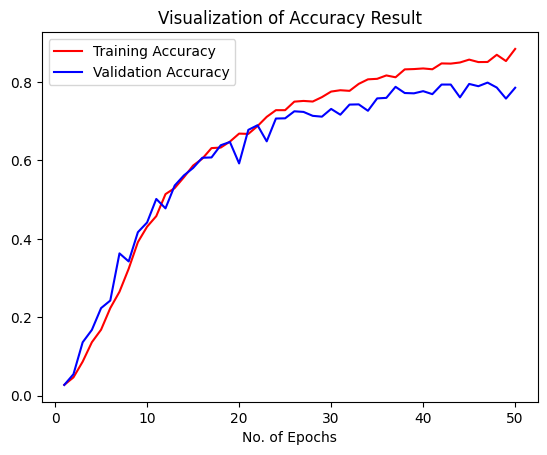

In [48]:
#epochs = range(1, len(training_history.history['accuracy']) + 1)
# epochs = [i for i in range(1,51)]
epochs = range(1, len(training_history.history['accuracy']) + 1)
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

### OTHER METRICS FOR EVALUATION


In [65]:
# valid_dataset = tf.keras.utils.image_dataset_from_directory(
#     "/content/drive/MyDrive/val",
#     labels="inferred",
#     label_mode="categorical",
#     batch_size=32,
#     image_size=(128, 128),
#     shuffle=False
# )

# # Save class names before transformations
# class_names = valid_dataset.class_names

# # Now modify the dataset
# # valid_dataset = valid_dataset.map(lambda x, y: (x/255.0, y))  # Example normalization

# # print("Class Names:", class_names)  # Still accessible


Found 3795 files belonging to 37 classes.


In [66]:

test_set= tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",  # Direct path to validation images
    labels="inferred",
    label_mode="categorical",
     color_mode="rgb",
    batch_size=1,
    image_size=(128,128),
    shuffle=False,  # No shuffling for validation set
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_names = valid_dataset.class_names

Found 3795 files belonging to 37 classes.


In [67]:
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

3795/3795 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step


<tf.Tensor: shape=(3795,), dtype=int64, numpy=array([4, 4, 4, ..., 4, 4, 4])>

In [68]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(3795,), dtype=int64, numpy=array([ 0,  0,  0, ..., 36, 36, 36])>

In [71]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)
# Precision Recall Fscore
print(classification_report(Y_true, predicted_categories, target_names=class_names))


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.45      0.04      0.07       126
                                 Apple___Black_rot       0.45      0.47      0.46       125
                          Apple___Cedar_apple_rust       0.50      0.36      0.42        55
                                   Apple___healthy       0.00      0.00      0.00       109
                               Blueberry___healthy       0.05      0.99      0.10       100
          Cherry_(including_sour)___Powdery_mildew       0.64      0.09      0.16       100
                 Cherry_(including_sour)___healthy       0.53      0.17      0.25       102
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.34      0.78      0.48       103
                       Corn_(maize)___Common_rust_       1.00      0.03      0.05       109
               Corn_(maize)___Northern_Leaf_Blight       0.78      0.07      0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CONFUSION MATRIX


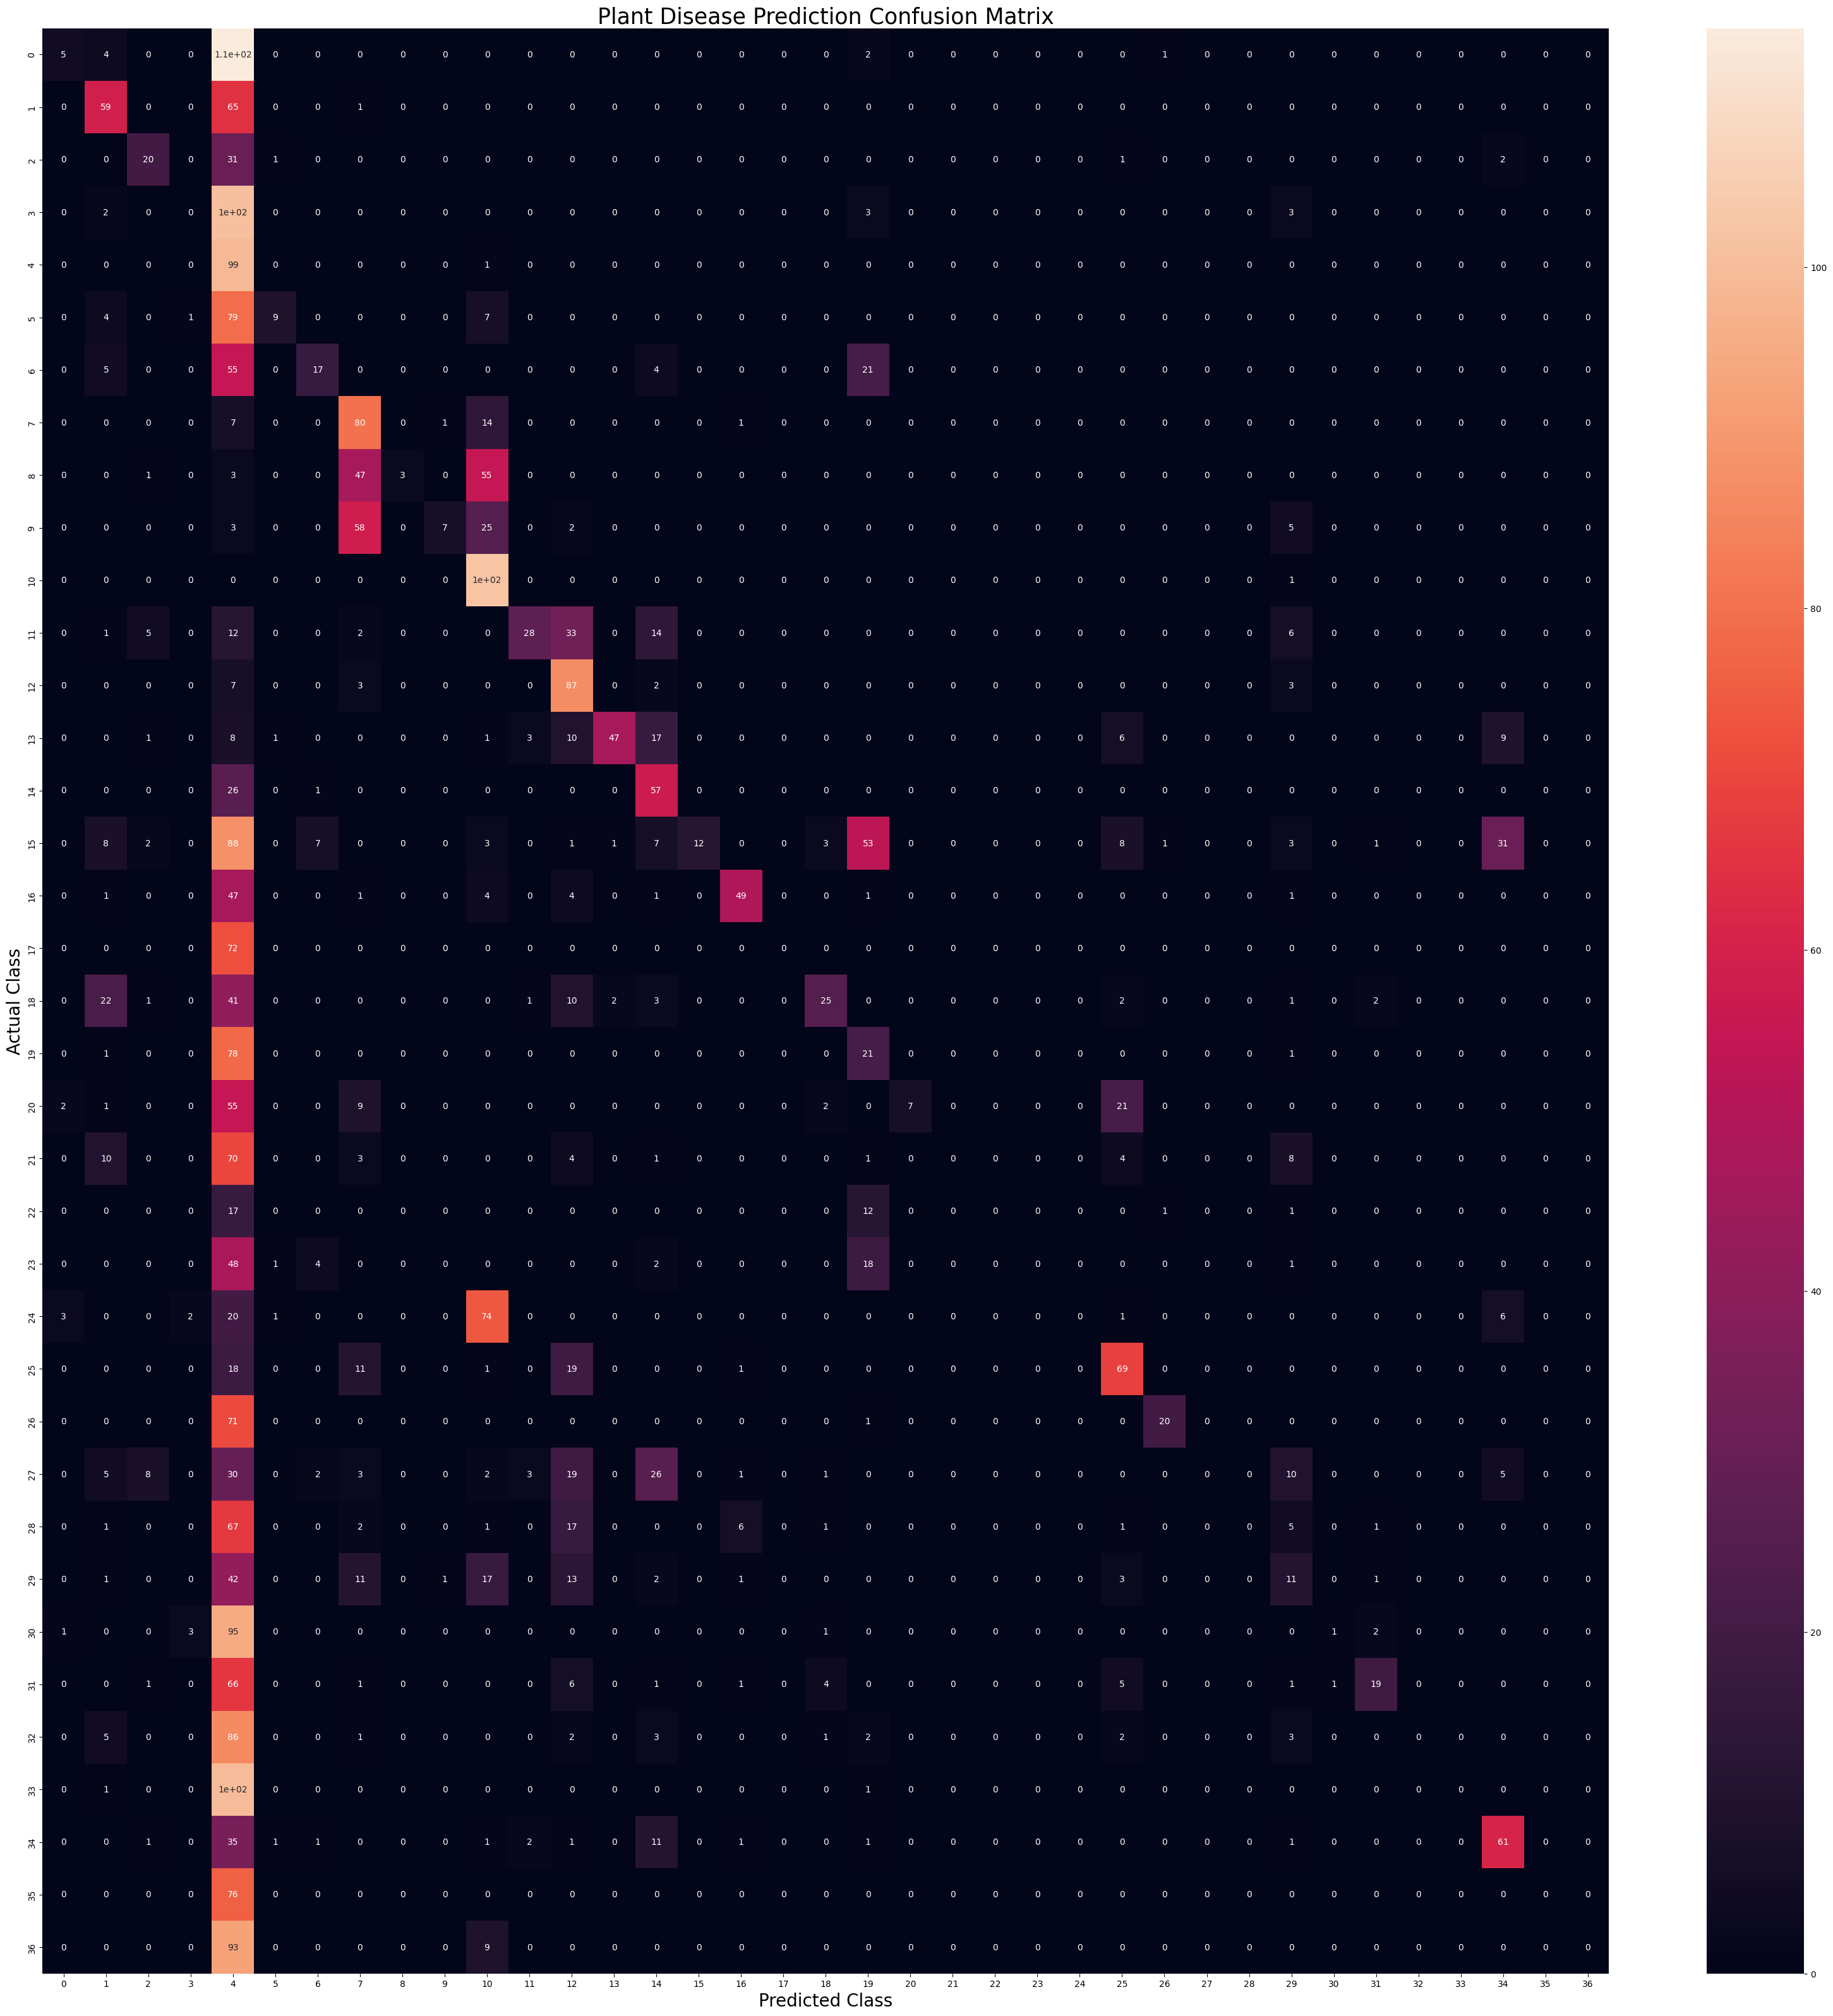

In [72]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

Found 3813 files belonging to 37 classes.
Found 3795 files belonging to 37 classes.
Training Set Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Sept

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 63, 63, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 63, 63, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 30, 30, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 256)         │           1,0

 Total params: 5,785,285 (22.07 MB)

 Trainable params: 5,783,301 (22.06 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 69s 450ms/step - accuracy: 0.0320 - loss: 3.8461 - val_accuracy: 0.0200 - val_loss: 3.6106 - learning_rate: 1.0000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 52s 435ms/step - accuracy: 0.0312 - loss: 3.6442 - val_accuracy: 0.0271 - val_loss: 3.6132 - learning_rate: 1.0000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 74s 369ms/step - accuracy: 0.0245 - loss: 3.6381 - val_accuracy: 0.0269 - val_loss: 3.6175 - learning_rate: 1.0000e-04
Epoch 4/50
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.0260 - loss: 3.6216
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
120/120 ━━━━━━━━━━━━━━━━━━━━ 52s 434ms/step - accuracy: 0.0260 - loss: 3.6217 - val_accuracy: 0.0329 - val_loss: 3.6123 - learning_rate: 1.0000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 43s 358ms/step - accuracy: 0.0270 - loss: 3.6302 - val_accuracy: 0.0269 - val_loss: 3.6162 - learning_rate: 5.0000e-05
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 91s 433ms/st

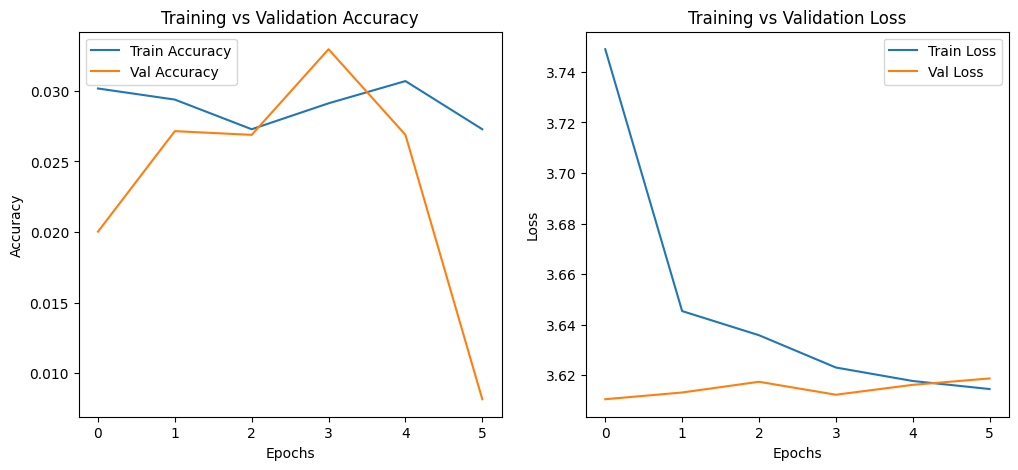

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",  # Path to training images
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True
)

# Load validation dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",  # Path to validation images
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False  # No shuffling for validation set
)

# Print class names
print("Training Set Classes:", train_dataset.class_names)
print("Validation Set Classes:", valid_dataset.class_names)

# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    tf.keras.layers.RandomBrightness(0.2)
])

# Normalize images (scale pixel values to [0,1])
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply Normalization First, Then Augmentation
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# Prefetching for Performance Improvement
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)

# CNN Model with Optimized Architecture
cnn = Sequential()

cnn.add(Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal', input_shape=(128,128,3)))
cnn.add(BatchNormalization())
cnn.add(tf.keras.layers.LeakyReLU(alpha=0.1))
cnn.add(Conv2D(32, (3,3), activation='relu'))
cnn.add(MaxPool2D(pool_size=(2,2), strides=2))
cnn.add(Dropout(0.2))

cnn.add(Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'))
cnn.add(BatchNormalization())
cnn.add(tf.keras.layers.LeakyReLU(alpha=0.1))
cnn.add(Conv2D(64, (3,3), activation='relu'))
cnn.add(MaxPool2D(pool_size=(2,2), strides=2))
cnn.add(Dropout(0.3))

cnn.add(Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal'))
cnn.add(BatchNormalization())
cnn.add(tf.keras.layers.LeakyReLU(alpha=0.1))
cnn.add(Conv2D(128, (3,3), activation='relu'))
cnn.add(MaxPool2D(pool_size=(2,2), strides=2))
cnn.add(Dropout(0.3))

cnn.add(Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal'))
cnn.add(BatchNormalization())
cnn.add(tf.keras.layers.LeakyReLU(alpha=0.1))
cnn.add(Conv2D(256, (3,3), activation='relu'))
cnn.add(MaxPool2D(pool_size=(2,2), strides=2))
cnn.add(Dropout(0.4))

cnn.add(Conv2D(512, (3,3), padding='same', kernel_initializer='he_normal'))
cnn.add(BatchNormalization())
cnn.add(tf.keras.layers.LeakyReLU(alpha=0.1))
cnn.add(Conv2D(512, (3,3), activation='relu'))
cnn.add(MaxPool2D(pool_size=(2,2), strides=2))
cnn.add(Dropout(0.4))

cnn.add(GlobalAveragePooling2D())  # Reduces Overfitting
cnn.add(Dense(1024, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(512, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(37, activation='softmax'))  # Output Layer (37 Classes)

# Compile Model with AdamW Optimizer and Learning Rate Scheduling
cnn.compile(optimizer=AdamW(learning_rate=0.0001, weight_decay=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

# Print Model Summary
cnn.summary()

# Learning Rate Scheduler & Early Stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train Model
history = cnn.fit(train_dataset,
                  validation_data=valid_dataset,
                  epochs=50,
                  callbacks=[reduce_lr, early_stopping])

# Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()
